**Bias-Variance-Tradeoff**

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("Datasets/supervised.csv")
df.head()

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
0,1,0.27,0,0.0,0,53,0,0,32,1000,955,0
1,1,0.00,2,0.0,0,44,0,0,286,2740,533,0
2,1,0.10,2,0.0,0,0,0,1,13,159,98,0
3,1,0.00,1,0.0,0,82,0,0,679,414,651,0
4,1,0.00,2,0.0,0,0,0,1,6,151,126,0


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score    


In [4]:
#Data Handling
X = df.drop("fake", axis=1)
y = df["fake"]

In [5]:
#train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)

In [6]:
#Model 
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [7]:
prediction = model.predict(X_test)

In [9]:
#Accuracy
from sklearn.metrics import accuracy_score
accuracy=mean_squared_error(y_test,prediction)
print(accuracy)

0.09543530076662311


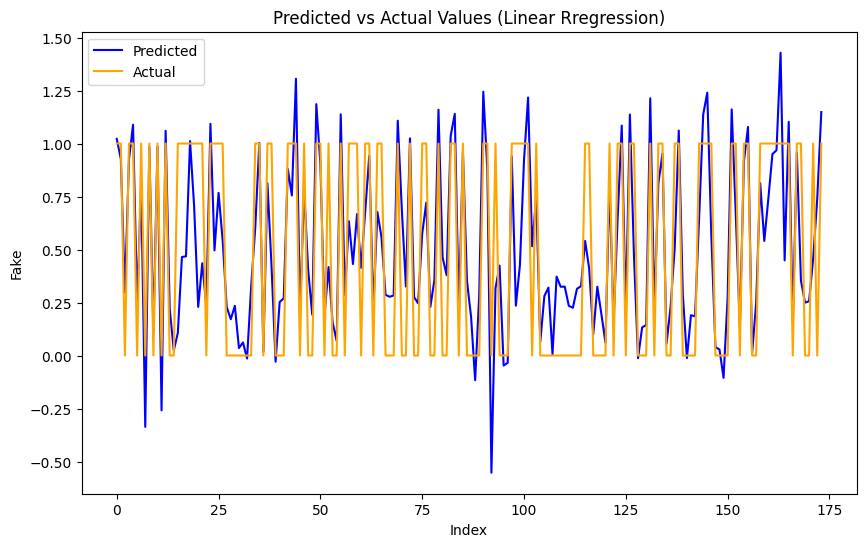

In [10]:
#plotting prediction v/s actual line graph
plt.figure(figsize=(10,6))
plt.plot(prediction, label='Predicted', color='blue')
plt.plot(y_test.values, label='Actual', color='orange')
plt.title('Predicted vs Actual Values (Linear Rregression)')
plt.xlabel('Index')
plt.ylabel('Fake')
plt.legend()
plt.show()

In [11]:
model2 = LogisticRegression()
model2.fit(X_train,y_train)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [12]:
prediction2 = model2.predict(X_test)
accuracy2 = accuracy_score(y_test, prediction2)
print(accuracy2)

0.9080459770114943


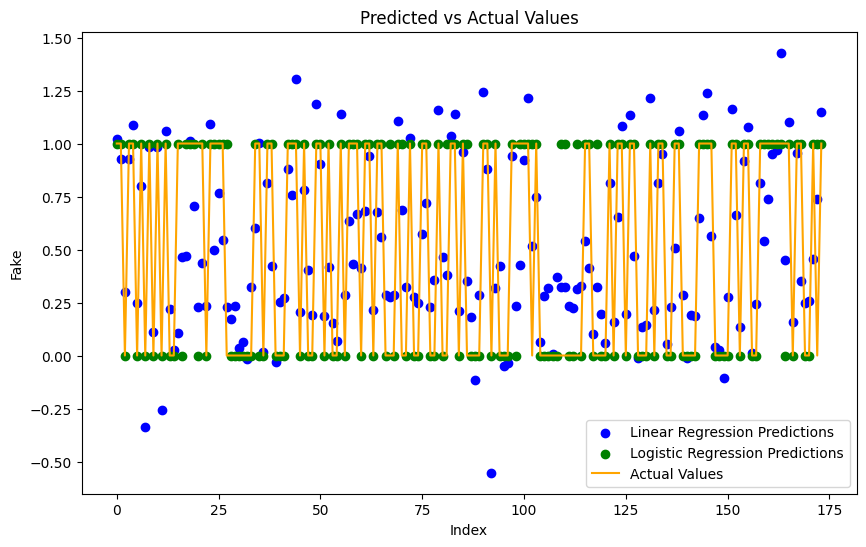

In [15]:
# Bias and Varaiance thorugh plotting
plt.figure(figsize=(10,6))
plt.scatter(range(len(prediction)), prediction, label='Linear Regression Predictions', color='blue')
plt.scatter(range(len(prediction2)), prediction2, label='Logistic Regression Predictions', color='green')
plt.plot(y_test.values, label='Actual Values', color='orange')
plt.title('Predicted vs Actual Values')
plt.xlabel('Index')
plt.ylabel('Fake')
plt.legend()
plt.show()

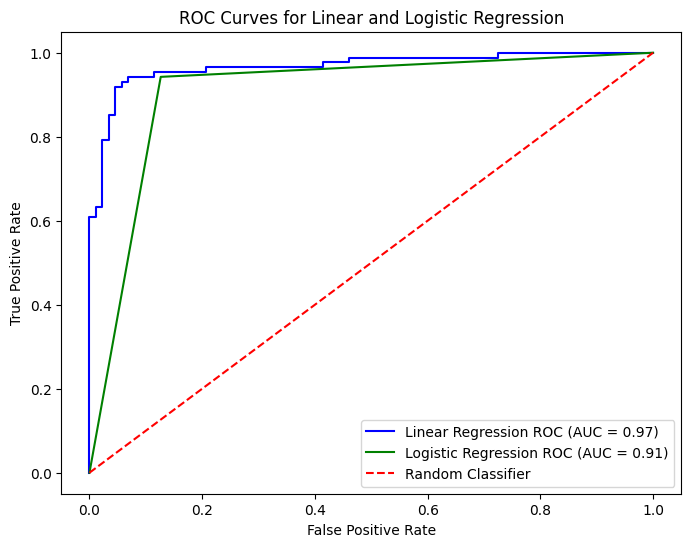

In [17]:
# ROC Curves

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr1, tpr1, _ = roc_curve(y_test, prediction)
fpr2, tpr2, _ = roc_curve(y_test, prediction2)

roc_auc1 = auc(fpr1, tpr1)
roc_auc2 = auc(fpr2, tpr2)

plt.figure(figsize=(8,6))
plt.plot(fpr1, tpr1, color='blue', label=f'Linear Regression ROC (AUC = {roc_auc1:.2f})')
plt.plot(fpr2, tpr2, color='green', label=f'Logistic Regression ROC (AUC = {roc_auc2:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Linear and Logistic Regression')
plt.legend()
plt.show()

In [18]:
# random forest
from sklearn.ensemble import RandomForestClassifier
model3 = RandomForestClassifier()
model3.fit(X_train, y_train)
prediction3 = model3.predict(X_test)
accuracy3 = accuracy_score(y_test, prediction3)
print(accuracy3)

0.9137931034482759


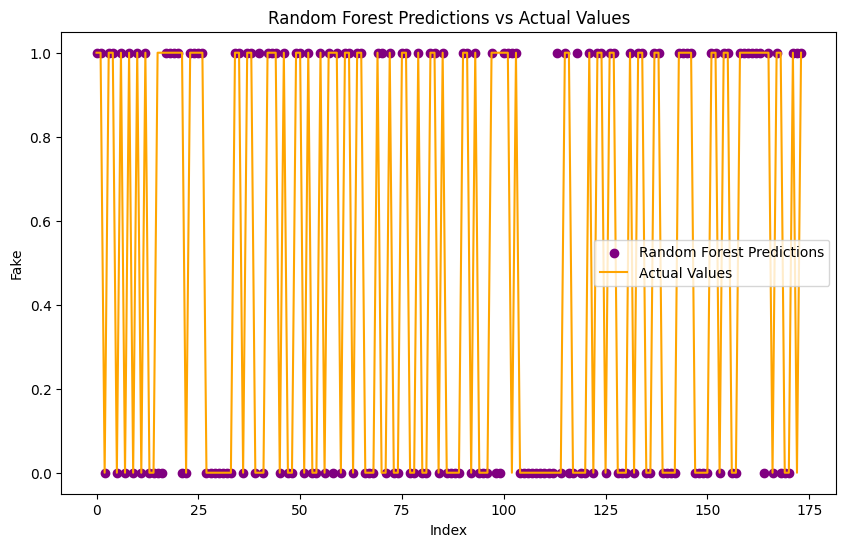

In [19]:
#plotting random forest predictions with actual values
plt.figure(figsize=(10,6))
plt.scatter(range(len(prediction3)), prediction3, label='Random Forest Predictions', color='purple')
plt.plot(y_test.values, label='Actual Values', color='orange')
plt.title('Random Forest Predictions vs Actual Values')
plt.xlabel('Index')
plt.ylabel('Fake')
plt.legend()
plt.show()

In [20]:
print(mean_squared_error(prediction3, y_test))

0.08620689655172414


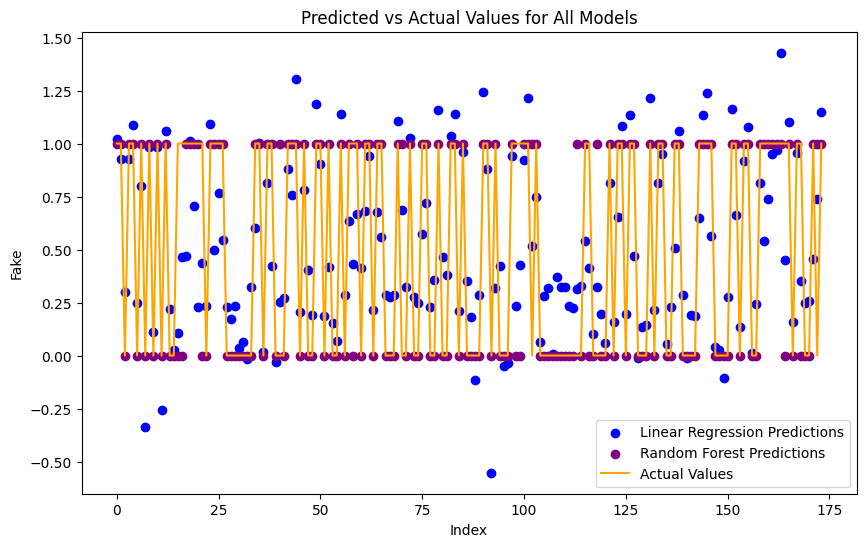

In [22]:
#Comparision of all three models
plt.figure(figsize=(10,6))
plt.scatter(range(len(prediction)), prediction, label='Linear Regression Predictions', color='blue')
#plt.scatter(range(len(prediction2)), prediction2, label='Logistic Regression Predictions', color='green')
plt.scatter(range(len(prediction3)), prediction3, label='Random Forest Predictions', color='purple')
plt.plot(y_test.values, label='Actual Values', color='orange')
plt.title('Predicted vs Actual Values for All Models')
plt.xlabel('Index')     
plt.ylabel('Fake')
plt.legend()
plt.show()